# Generate typical days
A code that extracts all the temperature and irradiance data as forecasted by models and create typical days

In [295]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sqlalchemy import text
from src.python import connect_SQL_alchemy
from tsam.timeseriesaggregation import TimeSeriesAggregation

import math
from datetime import datetime, timezone

In [296]:
engine = connect_SQL_alchemy()

query = text("""
        SELECT 
             gcm,
             ssp, 
             time,
             variable,
             value
        FROM belgium_res
        WHERE 
            time >= '2019-01-01' AND 
            time < '2023-01-01' AND 
            (variable = '2m Temperature' OR variable = 'Short Wave Downward')
        ORDER BY gcm, ssp, time,variable;
        """)

# Execute and load into DataFrame
timeserie = pd.read_sql_query(query, engine, parse_dates=True)

# 1 Solar gains

/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_42853/1608873486.py:78: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dt_winter = pd.Series(pd.date_range(
/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_42853/1608873486.py:84: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dt_summer = pd.Series(pd.date_range(


(0.0, 24.0)

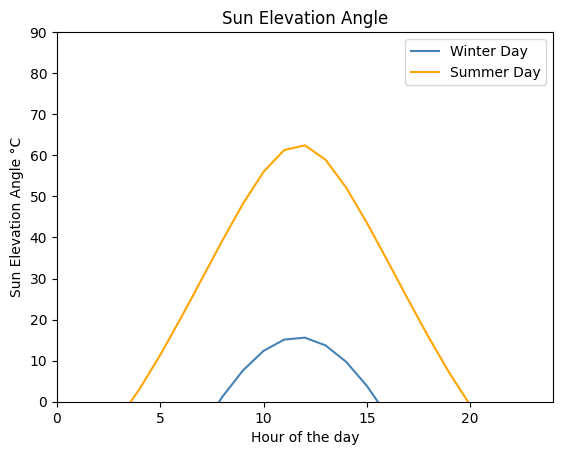

In [297]:
def sun_elevation_belgium(dt_utc):
    """
    Estimate the sun elevation angle (radians above horizon) in Belgium
    for given UTC datetime(s).

    Assumes input times are UTC and performs all calculations in UTC.
    No timezone or DST corrections are applied.

    Parameters:
    -----------
    dt_utc : datetime, pd.Timestamp, or pd.Series
        Datetime object(s) in UTC.

    Returns:
    --------
    float or pd.Series
        Sun elevation angle(s) in radians.
    """

    # Normalize input to pandas Series
    scalar_input = False
    if not isinstance(dt_utc, pd.Series):
        scalar_input = True
        dt_utc = pd.Series([pd.Timestamp(dt_utc)])

    # Extract UTC components
    n = dt_utc.dt.dayofyear.astype(float).values
    hour_frac = (
        dt_utc.dt.hour.values
        + dt_utc.dt.minute.values / 60
        + dt_utc.dt.second.values / 3600
    )

    # Belgium coordinates (Brussels)
    latitude_rad = np.radians(50.85)
    longitude_deg = 4.35  # degrees east

    # Solar declination (approximation)
    decl_rad = np.radians(
        23.45 * np.sin(np.radians(360 * (284 + n) / 365))
    )

    # Equation of time (minutes)
    B = np.radians(360 * (n - 81) / 365)
    eot = (
        9.87 * np.sin(2 * B)
        - 7.53 * np.cos(B)
        - 1.5 * np.sin(B)
    )

    # Solar time (hours) using UTC directly
    solar_time = hour_frac + (eot + 4 * longitude_deg) / 60

    # Hour angle
    hour_angle_rad = np.radians(15 * (solar_time - 12))

    # Solar elevation
    sin_elev = (
        np.sin(latitude_rad) * np.sin(decl_rad)
        + np.cos(latitude_rad) * np.cos(decl_rad) * np.cos(hour_angle_rad)
    )

    sin_elev = np.clip(sin_elev, -1.0, 1.0)
    elevation_rad = np.arcsin(sin_elev)

    result = pd.Series(
        elevation_rad,
        index=dt_utc.index,
        name="sun_elevation"
    )

    if scalar_input:
        return float(result.iloc[0])

    return result

# Winter and summer example dates (UTC)
dt_winter = pd.Series(pd.date_range(
    start="2024-12-21 00:00:00",
    end="2024-12-21 23:00:00",
    freq="1H"
))

dt_summer = pd.Series(pd.date_range(
    start="2024-06-21 00:00:00",
    end="2024-06-21 23:00:00",
    freq="1H"
))

# Compute sun elevation
elev_winter = sun_elevation_belgium(dt_winter)
elev_summer = sun_elevation_belgium(dt_summer)

# Convert to degrees only for inspection
elev_winter_deg = np.degrees(elev_winter)
elev_summer_deg = np.degrees(elev_summer)
plt.plot(elev_winter_deg, label = 'Winter Day', color = 'steelblue')
plt.plot(elev_summer_deg, label = 'Summer Day', color = 'orange')
plt.title('Sun Elevation Angle')
plt.legend()
plt.xlabel('Hour of the day')
plt.ylabel('Sun Elevation Angle °C')
plt.ylim(0,90)
plt.xlim(0,24)

In [298]:
df = timeserie.copy()
pivot_df = df.pivot(index = ['gcm','ssp','time'], columns = 'variable',values = 'value').reset_index().rename(columns= {'2m Temperature':'Temperature',"Short Wave Downward": 'Irradiance'})
pivot_df['Solar gains'] = pivot_df['Irradiance'] * (1+np.cos(sun_elevation_belgium(pivot_df['time']))) / 2


In [300]:

aggregation = TimeSeriesAggregation(
    pivot_df[['Temperature','Solar gains']],
    resolution=1,
    noTypicalPeriods=16,
    hoursPerPeriod=24,
    clusterMethod='k_means',
    addPeakMin = ['Temperature'],  # Column name as string
    addPeakMax = ['Temperature'],  # Column name as string  
    extremePeriodMethod='replace_cluster_center',
    weightDict = {'Temperature':100,
                  'Solar gains':0}
)

typical_periods = aggregation.createTypicalPeriods()


weight of "Solar gains" set to the minmal tolerable weighting


In [ ]:
# Create a copy of the original dataframe
df_annotated = pivot_df.copy()

# Get the cluster assignments from the aggregation
# clusterOrder tells us which typical period each original period belongs to
cluster_order = aggregation.clusterOrder

# Since you have hoursPerPeriod=24, each value in clusterOrder represents a 24-hour period
# We need to repeat each cluster assignment 24 times (once per hour)
typical_period_assignments = np.repeat(cluster_order, 24)

# Make sure it matches the dataframe length
# (trim if necessary in case of any mismatch)
typical_period_assignments = typical_period_assignments[:len(df_annotated)]

# Add the typical period column
df_annotated['typical_period'] = typical_period_assignments

# Create timestep within each typical period (0-23 for each day)
# This shows which hour within the typical day represents each record
timestep_within_period = np.tile(np.arange(24), len(cluster_order))[:len(df_annotated)]
df_annotated['typical_timestep'] = timestep_within_period

# Now df_annotated has:
# - All original columns (gcm, ssp, time, temperature, etc.)
# - typical_period: which of the 12 typical days represents this timestep
# - typical_timestep: which hour (0-23) within that typical day
# print(df_annotated.head(30))
print(f"\nShape: {df_annotated.shape}")
print(f"\nTypical periods used: {sorted(df_annotated['typical_period'].unique())}")
df_annotated


Shape: (841536, 8)

Typical periods used: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


variable,gcm,ssp,time,Temperature,Irradiance,Solar gains,typical_period,typical_timestep
0,CMCC-CM2-SR5,ssp126,2019-01-01 00:30:00,5.538376,0.0,0.0,13,0
1,CMCC-CM2-SR5,ssp126,2019-01-01 01:30:00,5.408974,0.0,0.0,13,1
2,CMCC-CM2-SR5,ssp126,2019-01-01 02:30:00,5.343876,0.0,0.0,13,2
3,CMCC-CM2-SR5,ssp126,2019-01-01 03:30:00,5.140580,0.0,0.0,13,3
4,CMCC-CM2-SR5,ssp126,2019-01-01 04:30:00,4.943552,0.0,0.0,13,4
...,...,...,...,...,...,...,...,...
841531,NorESM2-MM,ssp585,2022-12-31 19:30:00,7.730865,0.0,0.0,0,19
841532,NorESM2-MM,ssp585,2022-12-31 20:30:00,7.556525,0.0,0.0,0,20
841533,NorESM2-MM,ssp585,2022-12-31 21:30:00,7.676116,0.0,0.0,0,21
841534,NorESM2-MM,ssp585,2022-12-31 22:30:00,8.057172,0.0,0.0,0,22


In [ ]:


# # saving typical days
typical_periods.reset_index().rename(columns={'level_0':'td', 
                                              'TimeStep':'th',
                                              'Solar gains':'solar_gains',
                                              'Temperature':'temperature'}).to_sql(name = 'td_description',
                                                                                   if_exists = 'replace',
                                                                                   con = engine)


# saving typical weights
weights = df_annotated.loc[df_annotated['typical_timestep']==12,['gcm','ssp','typical_period','time']]
weights['decade'] = weights['time'].apply(lambda x: f"{str(x)[:3]}0s")
weights2 = weights.groupby(['gcm','ssp','decade','typical_period']).count().reset_index().rename(columns={'time':'weight','typical_period':'td'})
weights2.to_sql(name = 'td_decade_weight',
                if_exists = 'replace',
                con = engine)


# # saving mapping
df_annotated[['ssp','gcm','time','typical_period','typical_timestep']].rename(columns={'typical_period':'td',
                                                                                       'typical_timestep':'th'}).to_sql(name = 'td_mapping',
                                                                                                                        if_exists = 'replace',
                                                                                                                        con = engine)


536

Sorted typical periods by average Temperature:
  Typical Period 0: -12.97
  Typical Period 1: -1.13
  Typical Period 2: 2.07
  Typical Period 3: 4.29
  Typical Period 4: 5.57
  ...
  Typical Period 15: 27.34


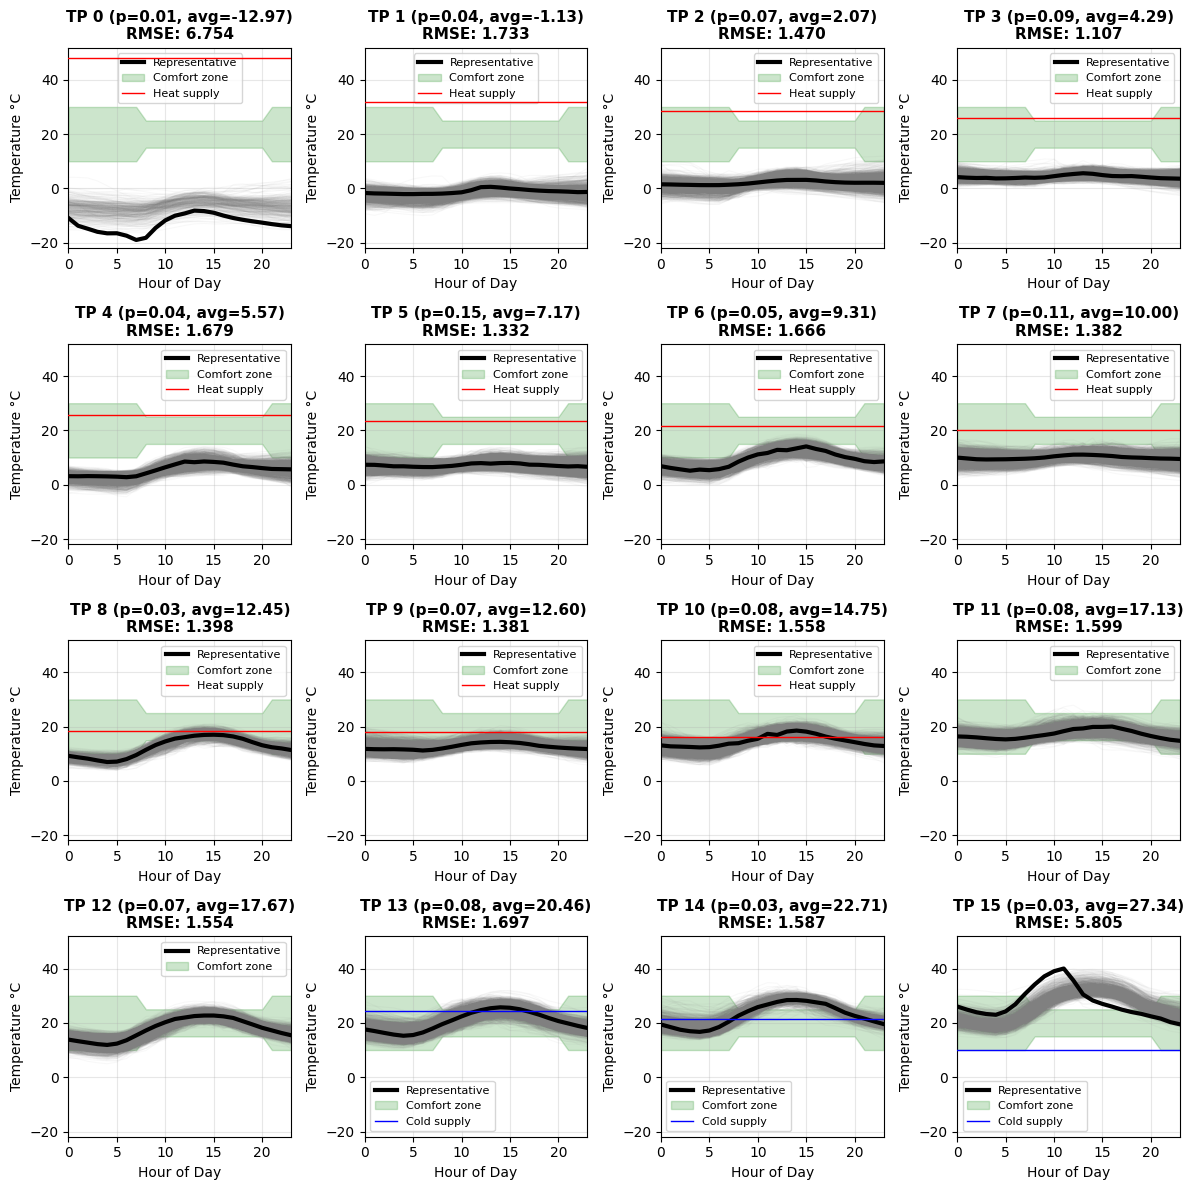

Sorted typical periods by average Temperature:
  Typical Period 0: -12.97
  Typical Period 1: -1.13
  Typical Period 2: 2.07
  Typical Period 3: 4.29
  Typical Period 4: 5.57
  ...
  Typical Period 15: 27.34


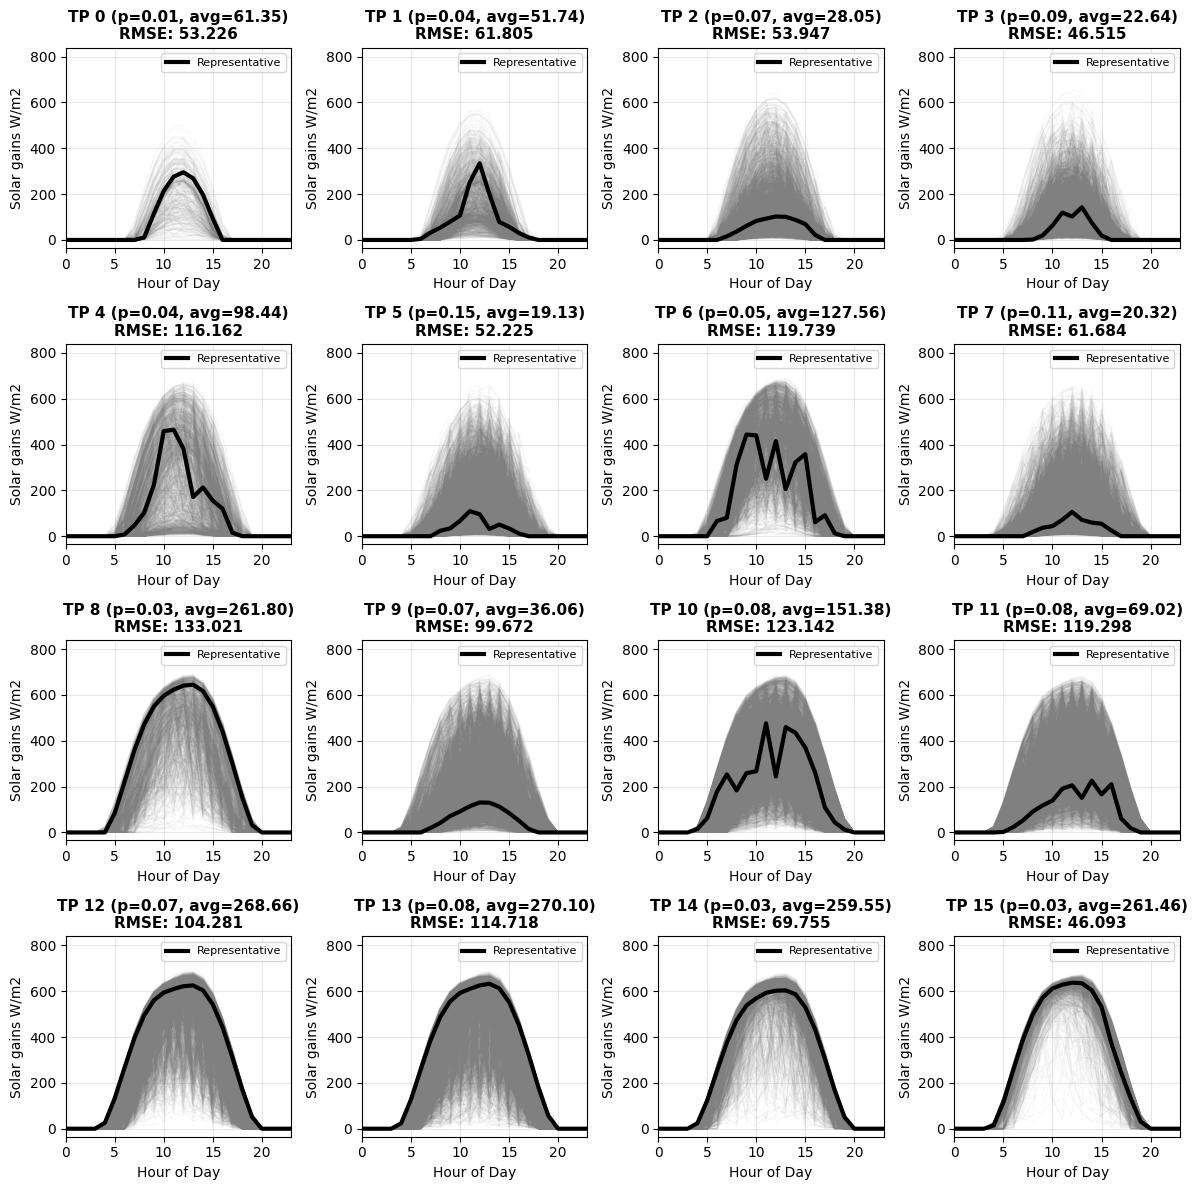

In [294]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_typical_periods_with_originals(df_annotated, typical_periods, aggregation, 
                                        variable='temperature', n_cols=4, sort_by_avg=True):
    """
    For each typical period, plot:
    1. The representative curve (bold, dark, alpha=1)
    2. All original curves it represents (light, thin, alpha<1)
    With RMSE in the title
    
    Parameters:
    -----------
    sort_by_avg : bool
        If True, sort typical periods by their average value (coldest to warmest)
    """
    n_typical = aggregation.noTypicalPeriods
    hours_per_period = aggregation.hoursPerPeriod
    
    # SORTING SECTION
    if sort_by_avg:
        # Calculate average for each typical period
        avg_values = []
        for tp in range(n_typical):
            start = tp * hours_per_period
            end = start + hours_per_period
            if isinstance(typical_periods, pd.DataFrame):
                avg_val = typical_periods.iloc[start:end][['Temperature']].values.mean()
            else:
                avg_val = typical_periods[start:end][['Temperature']].mean()
            avg_values.append(avg_val)
        
        # Create sorting index (from coldest to warmest)
        sort_index = np.argsort(avg_values)
        
        # Create a mapping from old cluster ID to new sorted cluster ID
        cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(sort_index)}
        
        # Reorder typical_periods
        sorted_typical_periods = []
        for new_id in range(n_typical):
            old_id = sort_index[new_id]
            start = old_id * hours_per_period
            end = start + hours_per_period
            sorted_typical_periods.append(typical_periods[start:end])
        
        if isinstance(typical_periods, pd.DataFrame):
            sorted_typical_periods = pd.concat(sorted_typical_periods, ignore_index=True)
        else:
            sorted_typical_periods = np.concatenate(sorted_typical_periods)
        
        # Update df_annotated with new sorted cluster IDs
        df_annotated = df_annotated.copy()
        df_annotated['typical_period'] = df_annotated['typical_period'].map(cluster_mapping)
        
        typical_periods = sorted_typical_periods
        
        print(f"Sorted typical periods by average {'Temperature'}:")
        for i in range(min(5, n_typical)):
            print(f"  Typical Period {i}: {avg_values[sort_index[i]]:.2f}")
        if n_typical > 5:
            print(f"  ...")
            print(f"  Typical Period {n_typical-1}: {avg_values[sort_index[-1]]:.2f}")
    
    # Calculate grid layout
    n_rows = int(np.ceil(n_typical / n_cols))
    
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    axes = axes.flatten() if n_typical > 1 else [axes]
    
    min_value = df_annotated[[variable]].min().iloc[0]
    max_value = df_annotated[[variable]].max().iloc[0]
    delta = max_value - min_value

    for tp in range(n_typical):
        ax = axes[tp]
        
        # Get the representative curve for this typical period
        typical_start = tp * hours_per_period
        typical_end = typical_start + hours_per_period
        
        # Extract as numpy array (typical_periods might be DataFrame or array)
        if isinstance(typical_periods, pd.DataFrame):
            representative_curve = typical_periods.iloc[typical_start:typical_end][[variable]].values.flatten()
        else:
            representative_curve = typical_periods[typical_start:typical_end][[variable]]
        
        # Get all original periods that belong to this cluster
        original_periods = df_annotated[df_annotated['typical_period'] == tp]
        
        # Group by the original period (every 24 consecutive hours)
        # We need to identify unique periods that map to this typical period
        original_periods = original_periods.copy()
        original_periods['period_id'] = original_periods.groupby(
            (original_periods['typical_timestep'] == 0).cumsum()
        ).ngroup()
        
        # Plot all original curves (light, thin)
        rmse_values = []
        for period_id in original_periods['period_id'].unique():
            period_data = original_periods[original_periods['period_id'] == period_id]
            
            if len(period_data) == hours_per_period:  # Complete period
                original_curve = period_data[variable].values
                timesteps = range(hours_per_period)
                
                # Plot original curve
                ax.plot(timesteps, original_curve, 
                       color='gray', alpha=0.05, linewidth=0.8)
                
                # Calculate RMSE for this curve
                rmse = np.sqrt(np.mean((original_curve - representative_curve)**2))
                rmse_values.append(rmse)
        
        # Plot representative curve (bold, dark)
        ax.plot(range(hours_per_period), representative_curve, 
               color='black', alpha=1.0, linewidth=3, 
               label='Representative', zorder=10)
        
        if variable == 'Temperature':
            hours = np.arange(hours_per_period)
            T_up = np.ones(np.size(hours)) * 30
            T_up[(8 <= hours) * (hours <= 20)] = 25
            T_low = np.ones(np.size(hours)) * 10
            T_low[(8 <= hours) * (hours <= 20)] = 15
            
            dT_heat = T_low - representative_curve
            dT_heat[dT_heat < 0 ] = 0
            dT_cold = representative_curve - T_up
            dT_cold[dT_cold < 0 ] = 0
            T_heat_supply = np.max(T_low + dT_heat)*np.ones(np.size(hours))
            T_cold_supply = np.min(T_up - dT_cold)*np.ones(np.size(hours))

            ax.fill_between(range(hours_per_period), T_low, T_up, 
                            color='green', alpha = 0.2,
                            label='Comfort zone', zorder=0)
            # ax.plot(range(hours_per_period), T_up, 
            #         color='red', alpha=1.0, linewidth=1, 
            #         linestyle = 'dashed',
            #         label=None, zorder=10)
            
            # ax.plot(range(hours_per_period), T_low, 
            #         color='red', alpha=1.0, linewidth=1, 
            #         linestyle = 'dashed',
            #         label='Indoor comfort level', zorder=10)
            
            if ((T_low - representative_curve) > 0).any():
                ax.plot(range(hours_per_period), T_heat_supply, 
                    color='red', alpha=1.0, linewidth=1, 
                    label='Heat supply', zorder=10)
            
            if ((representative_curve - T_up) > 0).any():
                ax.plot(range(hours_per_period), T_cold_supply, 
                    color='blue', alpha=1.0, linewidth=1, 
                    label='Cold supply', zorder=10)

        # Calculate overall RMSE for this typical period
        overall_rmse = np.mean(rmse_values) if rmse_values else 0
        
        # Calculate average value for this typical period
        avg_temp = representative_curve.mean()
        
        # Formatting
        ax.set_xlabel('Hour of Day', fontsize=10)
        if variable == 'Temperature':
            ax.set_ylabel('Temperature °C', fontsize=10)
        elif variable == 'Solar gains':
            ax.set_ylabel('Solar gains W/m2', fontsize=10)
        else:
            ax.set_ylabel(variable.capitalize(), fontsize=10)
        ax.set_title(f'TP {tp} (p={len(original_periods["period_id"].unique())*24/len(df_annotated):.2f}, avg={avg_temp:.2f})\n'
                    f'RMSE: {overall_rmse:.3f}', 
                    fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(min_value - 0.05 * delta,max_value + 0.2 * delta)
        ax.set_xlim(0,23)
        
        ax.legend(#loc='lower right', 
                  fontsize=8)
    
    # Hide unused subplots
    for idx in range(n_typical, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return fig, df_annotated


fig, df_annotated_sorted = plot_typical_periods_with_originals(
    df_annotated, typical_periods, aggregation, 
    variable='Temperature', sort_by_avg=True
)
fig.savefig('output/typical_days_plots/temperature.pdf')

fig, df_annotated_sorted = plot_typical_periods_with_originals(
    df_annotated, typical_periods, aggregation, 
    variable='Solar gains', sort_by_avg=True
)

fig.savefig('output/typical_days_plots/irradiance.pdf')